# Revenue

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("Coffee Shop Sales.csv")

In [10]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]
print(df[["transaction_qty", "unit_price", "revenue"]])

        transaction_qty  unit_price  revenue
0                     2        3.00     6.00
1                     2        3.10     6.20
2                     2        4.50     9.00
3                     1        2.00     2.00
4                     2        3.10     6.20
...                 ...         ...      ...
149111                2        2.50     5.00
149112                2        3.00     6.00
149113                1        3.00     3.00
149114                1        3.75     3.75
149115                2        0.80     1.60

[149116 rows x 3 columns]


# סידור תאריכים

In [11]:
# Safer datetime parsing for mixed/invalid formats
if {"transaction_date", "transaction_time"}.issubset(df.columns):
    df["date"] = pd.to_datetime(
        df["transaction_date"],
        errors="coerce",
        dayfirst=True,
        format="mixed"
    )

    time_parsed = pd.to_datetime(
        df["transaction_time"],
        errors="coerce",
        format="mixed"
    )

    df["hour"] = time_parsed.dt.hour
    df["day_of_week"] = df["date"].dt.day_name()
    df["month"] = df["date"].dt.month

    print("New columns created: date, hour, day_of_week, month")
    print("Invalid dates:", int(df["date"].isna().sum()))
    print("Invalid times:", int(df["hour"].isna().sum()))
    print(df[["transaction_date", "transaction_time", "date", "hour", "day_of_week", "month"]])
else:
    print("Missing required columns. Available columns:")
    print(list(df.columns))

New columns created: date, hour, day_of_week, month
Invalid dates: 0
Invalid times: 0
       transaction_date transaction_time       date  hour day_of_week  month
0            01/01/2023         07:06:11 2023-01-01     7      Sunday      1
1            01/01/2023         07:08:56 2023-01-01     7      Sunday      1
2            01/01/2023         07:14:04 2023-01-01     7      Sunday      1
3            01/01/2023         07:20:24 2023-01-01     7      Sunday      1
4            01/01/2023         07:22:41 2023-01-01     7      Sunday      1
...                 ...              ...        ...   ...         ...    ...
149111       30/06/2023         20:18:41 2023-06-30    20      Friday      6
149112       30/06/2023         20:25:10 2023-06-30    20      Friday      6
149113       30/06/2023         20:31:34 2023-06-30    20      Friday      6
149114       30/06/2023         20:57:19 2023-06-30    20      Friday      6
149115       30/06/2023         20:57:19 2023-06-30    20      Frid

# general

סה״כ הכנסות
מספר עסקאות
ממוצע לעסקה
סטיית תקן של הממוצע 
(כדי לבדוק ממוצע לפי קטגוריה)

In [12]:
summary = pd.DataFrame({
    "metric": ["total_revenue", "num_transactions", "avg_order_value", "std_order_value"],
    "value": [
        df["revenue"].sum(),
        df["transaction_id"].nunique(),
        df["revenue"].sum() / df["transaction_id"].nunique(),
        df["revenue"].std()
    ]
})

summary["value"] = summary["value"].round(2)
print(summary)

             metric      value
0     total_revenue  698812.33
1  num_transactions  149116.00
2   avg_order_value       4.69
3   std_order_value       4.23


# ניתוח לפי קטגוריות

Product category: 
Total revenue
Average revenue
Transaction count
Quantity

In [13]:
category_summary = (
    df.groupby("product_category", dropna=False)
      .agg(
          total_revenue=("revenue", "sum"),
          average_revenue=("revenue", "mean"),
          median_revenue=("revenue", "median"),
          min_revenue=("revenue", "min"),
          p25_revenue=("revenue", lambda s: s.quantile(0.25)),
          p75_revenue=("revenue", lambda s: s.quantile(0.75)),
          max_revenue=("revenue", "max"),
          std_revenue=("revenue", "std"),
          transaction_count=("transaction_id", "nunique"),
          quantity=("transaction_qty", "sum")
      )
      .reset_index()
)

cols_to_round = [
    "total_revenue", "average_revenue", "median_revenue", "min_revenue",
    "p25_revenue", "p75_revenue", "max_revenue", "std_revenue"
]
category_summary[cols_to_round] = category_summary[cols_to_round].round(2)
print(category_summary)

     product_category  total_revenue  average_revenue  median_revenue  \
0              Bakery       82315.64             3.61            3.50   
1             Branded       13607.00            18.22           14.00   
2              Coffee      269952.45             4.62            4.20   
3        Coffee beans       40085.25            22.87           19.75   
4  Drinking Chocolate       72416.00             6.31            7.00   
5            Flavours        8408.80             1.24            1.60   
6           Loose Tea       11213.60             9.27            8.95   
7  Packaged Chocolate        4407.64             9.05            7.60   
8                 Tea      196405.95             4.32            5.00   

   min_revenue  p25_revenue  p75_revenue  max_revenue  std_revenue  \
0         2.65         3.25         3.75         9.00         0.58   
1        12.00        12.00        28.00        72.00         7.90   
2         2.00         3.00         6.00        17.00      

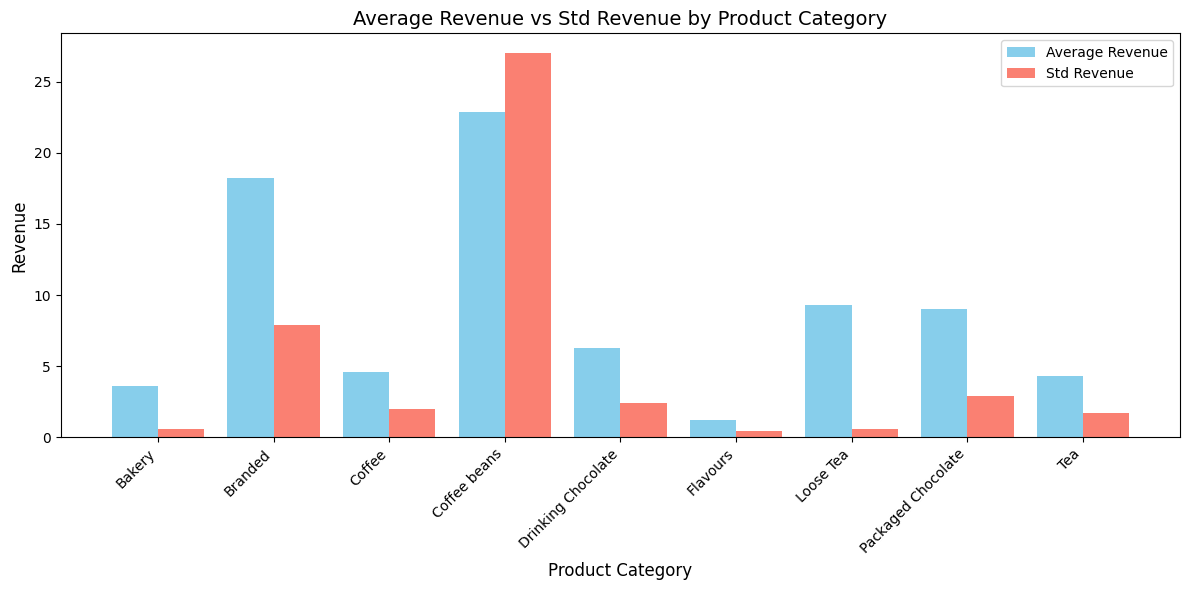

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(category_summary))
ax.bar([i - 0.2 for i in x], category_summary["average_revenue"], width=0.4, label="Average Revenue", color="skyblue")
ax.bar([i + 0.2 for i in x], category_summary["std_revenue"], width=0.4, label="Std Revenue", color="salmon")

ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Revenue", fontsize=12)
ax.set_title("Average Revenue vs Std Revenue by Product Category", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(category_summary["product_category"], rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

# ניתוח לפי סניף

Branch (ID / Location):
Total revenue
Average revenue
Std revenue
Transaction count
Quantity

In [15]:
branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]

branch_col = next((c for c in branch_candidates if c in df.columns), None)

if branch_col is None:
    print("No branch column found (ID/location).")
    print("Available columns:", list(df.columns))
else:
    branch_summary = (
        df.groupby(branch_col, dropna=False)
          .agg(
              total_revenue=("revenue", "sum"),
              average_revenue=("revenue", "mean"),
              median_revenue=("revenue", "median"),
              min_revenue=("revenue", "min"),
              p25_revenue=("revenue", lambda s: s.quantile(0.25)),
              p75_revenue=("revenue", lambda s: s.quantile(0.75)),
              max_revenue=("revenue", "max"),
              std_revenue=("revenue", "std"),
              transaction_count=("transaction_id", "nunique"),
              quantity=("transaction_qty", "sum")
          )
          .reset_index()
    )

    cols_to_round = [
        "total_revenue", "average_revenue", "median_revenue", "min_revenue",
        "p25_revenue", "p75_revenue", "max_revenue", "std_revenue"
    ]
    branch_summary[cols_to_round] = branch_summary[cols_to_round].round(2)
    print(branch_summary)

    store_location  total_revenue  average_revenue  median_revenue  \
0          Astoria      232243.91             4.59            3.75   
1   Hell's Kitchen      236511.17             4.66            3.75   
2  Lower Manhattan      230057.25             4.81            3.75   

   min_revenue  p25_revenue  p75_revenue  max_revenue  std_revenue  \
0          0.8          3.0          6.0         45.0         2.88   
1          0.8          3.0          6.0        360.0         5.84   
2          0.8          3.0          6.0         72.0         3.28   

   transaction_count  quantity  
0              50599     70991  
1              50735     71737  
2              47782     71742  


# ניתוח מוצרים ספציפיים

קיבוץ דו-שלבי:
1. Product Type
2. Product Detail

מטרות:
- Total revenue
- Average revenue
- Std revenue
- Transaction count
- Quantity
- זיהוי מוצר מוביל

In [16]:
type_candidates = ["product_type", "product type", "product_category"]
detail_candidates = ["product_detail", "product detail", "product"]

type_col = next((c for c in type_candidates if c in df.columns), None)
detail_col = next((c for c in detail_candidates if c in df.columns), None)
category_col = "product_category" if "product_category" in df.columns else None

if type_col is None or detail_col is None:
    print("Missing product type/detail columns.")
    print("Available columns:", list(df.columns))
else:
    group_cols = [type_col, detail_col]
    if category_col and category_col not in group_cols:
        group_cols.insert(1, category_col)

    product_summary = (
        df.groupby(group_cols, dropna=False)
          .agg(
              total_revenue=("revenue", "sum"),
              average_revenue=("revenue", "mean"),
              median_revenue=("revenue", "median"),
              min_revenue=("revenue", "min"),
              p25_revenue=("revenue", lambda s: s.quantile(0.25)),
              p75_revenue=("revenue", lambda s: s.quantile(0.75)),
              max_revenue=("revenue", "max"),
              std_revenue=("revenue", "std")
          )
          .reset_index()
          .sort_values("total_revenue", ascending=False)
    )

    cols_to_round = [
        "total_revenue", "average_revenue", "median_revenue", "min_revenue",
        "p25_revenue", "p75_revenue", "max_revenue", "std_revenue"
    ]
    product_summary[cols_to_round] = product_summary[cols_to_round].round(2)

    print("Top 10 products by total revenue:")
    print(product_summary.head(10))

    leader = product_summary.iloc[0]
    print("\nLeading product:")
    print(f"{type_col}: {leader[type_col]}")
    if category_col and category_col in product_summary.columns:
        print(f"{category_col}: {leader[category_col]}")
    print(f"{detail_col}: {leader[detail_col]}")
    print(f"total_revenue: {leader['total_revenue']}")
    print(f"average_revenue: {leader['average_revenue']}")
    print(f"median_revenue: {leader['median_revenue']}")
    print(f"min_revenue: {leader['min_revenue']}")
    print(f"p25_revenue: {leader['p25_revenue']}")
    print(f"p75_revenue: {leader['p75_revenue']}")
    print(f"max_revenue: {leader['max_revenue']}")
    print(f"std_revenue: {leader['std_revenue']}")

Top 10 products by total revenue:
             product_type    product_category                product_detail  \
52          Hot chocolate  Drinking Chocolate  Sustainably Grown Organic Lg   
50          Hot chocolate  Drinking Chocolate             Dark chocolate Lg   
4        Barista Espresso              Coffee                      Latte Rg   
1        Barista Espresso              Coffee                 Cappuccino Lg   
15        Brewed Chai tea                 Tea       Morning Sunrise Chai Lg   
3        Barista Espresso              Coffee                         Latte   
68  Premium brewed coffee              Coffee      Jamaican Coffee River Lg   
53          Hot chocolate  Drinking Chocolate  Sustainably Grown Organic Rg   
0        Barista Espresso              Coffee                    Cappuccino   
60  Organic brewed coffee              Coffee                  Brazilian Lg   

    total_revenue  average_revenue  median_revenue  min_revenue  p25_revenue  \
52       21151.7

# 10 מוצרים הכי נמכרים

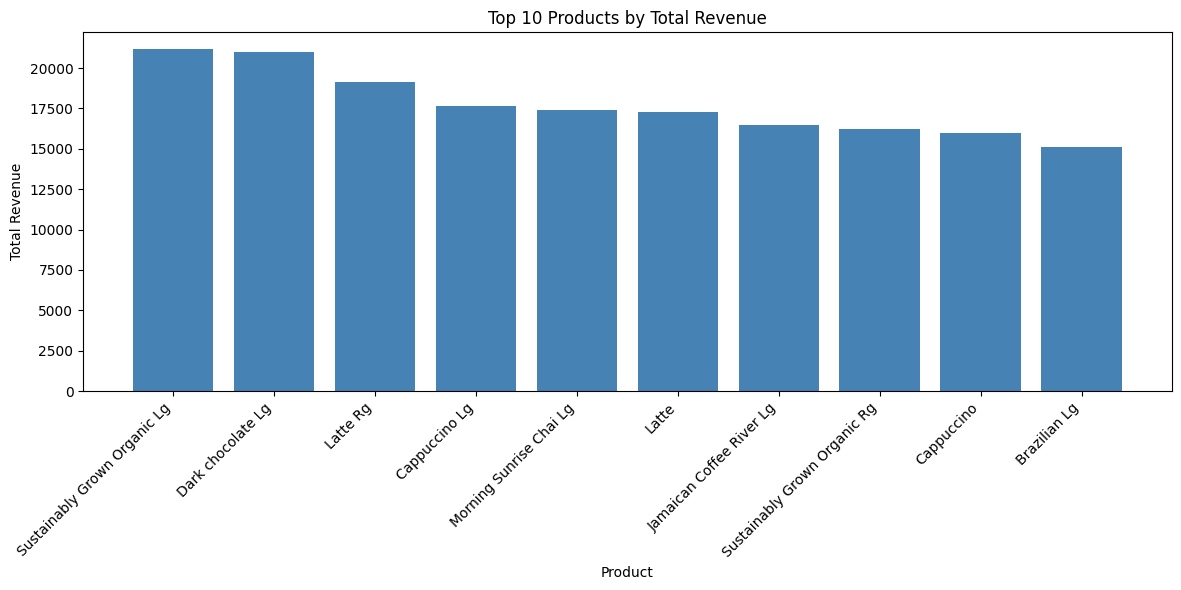

In [17]:
import matplotlib.pyplot as plt

if "product_summary" not in globals() or product_summary.empty:
    print("Run the product summary cell first.")
else:
    plot_df = product_summary.nlargest(10, "total_revenue").copy()
    plot_df["product_label"] = plot_df[detail_col].astype(str)

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["product_label"], plot_df["total_revenue"], color="steelblue")
    plt.title("Top 10 Products by Total Revenue")
    plt.xlabel("Product")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [18]:
if "product_summary" not in globals() or product_summary.empty:
    print("Run the product summary cell first.")
else:
    show_cols = [
        c for c in ["product_type", "product_category", "product_detail", "total_revenue", "average_revenue", "std_revenue"]
        if c in product_summary.columns
    ]

    bottom10_table = (
        product_summary.nsmallest(10, "total_revenue")[show_cols]
        .reset_index(drop=True)
    )

    print("Bottom 10 products by total revenue:")
    print(bottom10_table)

Bottom 10 products by total revenue:
         product_type    product_category                product_detail  \
0  Drinking Chocolate  Packaged Chocolate                Dark chocolate   
1           Black tea           Loose Tea                     Earl Grey   
2            Chai tea           Loose Tea         Spicy Eye Opener Chai   
3         Green beans        Coffee beans  Guatemalan Sustainably Grown   
4          Herbal tea           Loose Tea                   Lemon Grass   
5          Herbal tea           Loose Tea                    Peppermint   
6            Chai tea           Loose Tea        Traditional Blend Chai   
7           Black tea           Loose Tea             English Breakfast   
8           Green tea           Loose Tea            Serenity Green Tea   
9            Chai tea           Loose Tea          Morning Sunrise Chai   

   total_revenue  average_revenue  std_revenue  
0         755.20             6.40          0.0  
1        1270.90             8.95      

# טבלת 10 מוצרים הכי פחות מרוויחים

Bottom 10 products by total revenue

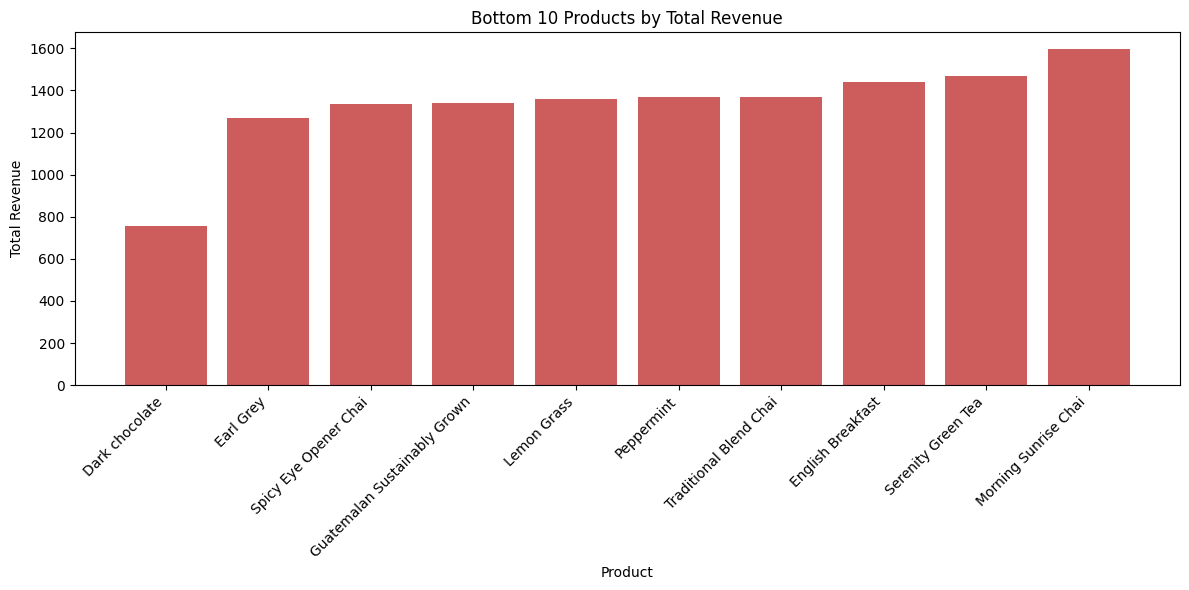

In [19]:
import matplotlib.pyplot as plt

if "product_summary" not in globals() or product_summary.empty:
    print("Run the product summary cell first.")
else:
    low_df = product_summary.nsmallest(10, "total_revenue").copy()
    low_df["product_label"] = low_df[detail_col].astype(str)

    plt.figure(figsize=(12, 6))
    plt.bar(low_df["product_label"], low_df["total_revenue"], color="indianred")
    plt.title("Bottom 10 Products by Total Revenue")
    plt.xlabel("Product")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# חישוב לפי זמנים שונים

In [20]:
# Revenue by month (total + by branch)
if "month" not in df.columns:
    print("Column month not found. Run the datetime block first.")
else:
    branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
    branch_col = next((c for c in branch_candidates if c in df.columns), None)

    revenue_by_month = (
        df.groupby("month", dropna=False)["revenue"]
          .sum()
          .reset_index(name="total_revenue")
    )

    if branch_col is not None:
        month_by_branch = (
            df.pivot_table(
                index="month",
                columns=branch_col,
                values="revenue",
                aggfunc="sum",
                fill_value=0
            )
            .reset_index()
        )
        month_by_branch.columns = ["month"] + [f"revenue_{str(c)}" for c in month_by_branch.columns[1:]]
        revenue_by_month = revenue_by_month.merge(month_by_branch, on="month", how="left")

    revenue_by_month = revenue_by_month.sort_values("month")
    num_cols = revenue_by_month.select_dtypes(include="number").columns
    revenue_by_month[num_cols] = revenue_by_month[num_cols].round(2)
    print(revenue_by_month)

   month  total_revenue  revenue_Astoria  revenue_Hell's Kitchen  \
0      1       81677.74         27313.66                27820.65   
1      2       76145.19         25105.34                25719.80   
2      3       98834.68         32835.43                33110.57   
3      4      118941.08         39477.61                40304.14   
4      5      156727.76         52428.76                52598.93   
5      6      166485.88         55083.11                56957.08   

   revenue_Lower Manhattan  
0                 26543.43  
1                 25320.05  
2                 32888.68  
3                 39159.33  
4                 51700.07  
5                 54445.69  


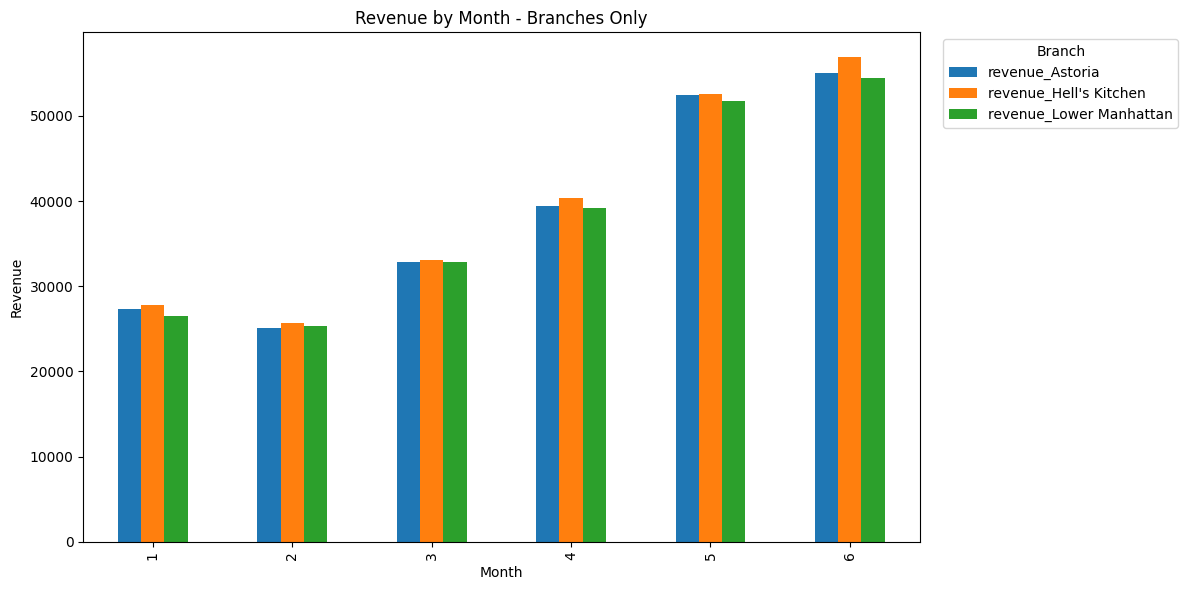

In [21]:
# Branch-only chart: revenue by month
if "revenue_by_month" not in globals() or revenue_by_month.empty:
    print("Run the month block first.")
else:
    branch_cols = [c for c in revenue_by_month.columns if c.startswith("revenue_")]

    if not branch_cols:
        print("No branch revenue columns found.")
    else:
        plot_df = revenue_by_month[["month"] + branch_cols].copy()
        plot_df = plot_df.set_index("month")

        ax = plot_df.plot(kind="bar", figsize=(12, 6))
        ax.set_title("Revenue by Month - Branches Only")
        ax.set_xlabel("Month")
        ax.set_ylabel("Revenue")
        ax.legend(title="Branch", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

In [22]:
# Revenue by day of week (total + by branch)
if "day_of_week" not in df.columns:
    print("Column day_of_week not found. Run the datetime block first.")
else:
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
    branch_col = next((c for c in branch_candidates if c in df.columns), None)

    revenue_by_day = (
        df.groupby("day_of_week", dropna=False)["revenue"]
          .sum()
          .reset_index(name="total_revenue")
    )

    if branch_col is not None:
        day_by_branch = (
            df.pivot_table(
                index="day_of_week",
                columns=branch_col,
                values="revenue",
                aggfunc="sum",
                fill_value=0
            )
            .reset_index()
        )
        day_by_branch.columns = ["day_of_week"] + [f"revenue_{str(c)}" for c in day_by_branch.columns[1:]]
        revenue_by_day = revenue_by_day.merge(day_by_branch, on="day_of_week", how="left")

    revenue_by_day["day_of_week"] = pd.Categorical(revenue_by_day["day_of_week"], categories=day_order, ordered=True)
    revenue_by_day = revenue_by_day.sort_values("day_of_week")
    num_cols = revenue_by_day.select_dtypes(include="number").columns
    revenue_by_day[num_cols] = revenue_by_day[num_cols].round(2)
    print(revenue_by_day)

  day_of_week  total_revenue  revenue_Astoria  revenue_Hell's Kitchen  \
1      Monday      101677.28         33928.29                33389.51   
5     Tuesday       99455.94         31816.76                34846.47   
6   Wednesday      100313.54         34244.63                33779.09   
4    Thursday      100767.78         34140.37                33468.06   
0      Friday      101373.00         33472.75                34743.18   
2    Saturday       96894.48         31845.93                32599.23   
3      Sunday       98330.31         32795.18                33685.63   

   revenue_Lower Manhattan  
1                 34359.48  
5                 32792.71  
6                 32289.82  
4                 33159.35  
0                 33157.07  
2                 32449.32  
3                 31849.50  


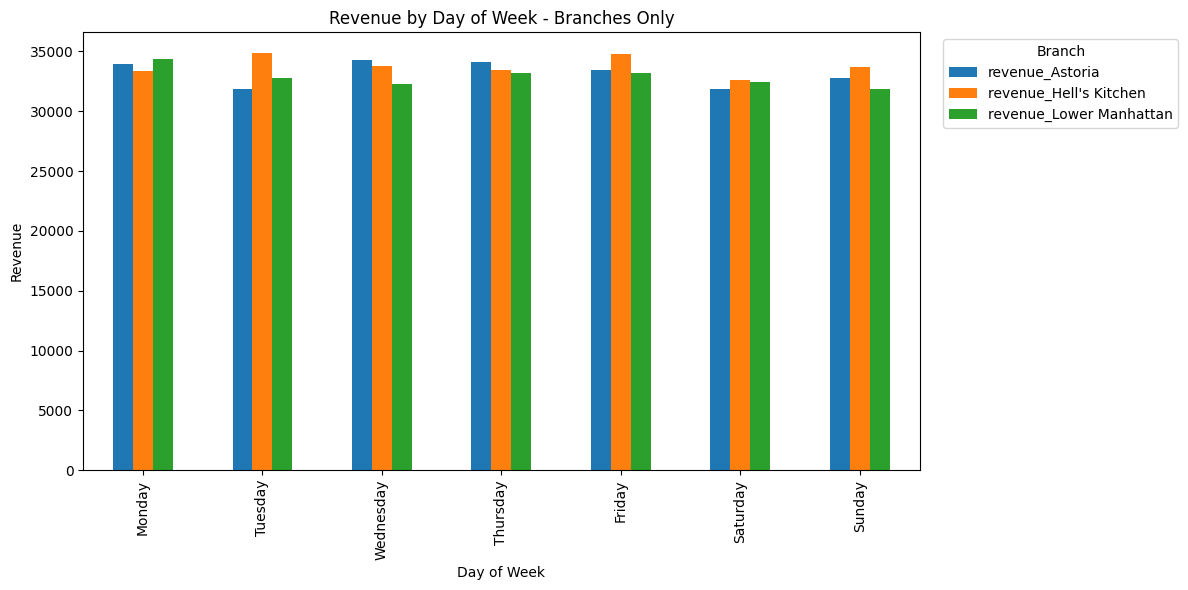

In [23]:
# Branch-only chart: revenue by day of week
if "revenue_by_day" not in globals() or revenue_by_day.empty:
    print("Run the day-of-week block first.")
else:
    branch_cols = [c for c in revenue_by_day.columns if c.startswith("revenue_")]

    if not branch_cols:
        print("No branch revenue columns found.")
    else:
        plot_df = revenue_by_day[["day_of_week"] + branch_cols].copy()
        plot_df = plot_df.set_index("day_of_week")

        ax = plot_df.plot(kind="bar", figsize=(12, 6))
        ax.set_title("Revenue by Day of Week - Branches Only")
        ax.set_xlabel("Day of Week")
        ax.set_ylabel("Revenue")
        ax.legend(title="Branch", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

In [24]:
# Revenue by hour (total + by branch)
if "hour" not in df.columns:
    print("Column hour not found. Run the datetime block first.")
else:
    branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
    branch_col = next((c for c in branch_candidates if c in df.columns), None)

    revenue_by_hour = (
        df.groupby("hour", dropna=False)["revenue"]
          .sum()
          .reset_index(name="total_revenue")
    )

    if branch_col is not None:
        hour_by_branch = (
            df.pivot_table(
                index="hour",
                columns=branch_col,
                values="revenue",
                aggfunc="sum",
                fill_value=0
            )
            .reset_index()
        )
        hour_by_branch.columns = ["hour"] + [f"revenue_{str(c)}" for c in hour_by_branch.columns[1:]]
        revenue_by_hour = revenue_by_hour.merge(hour_by_branch, on="hour", how="left")

    revenue_by_hour = revenue_by_hour.sort_values("hour")
    num_cols = revenue_by_hour.select_dtypes(include="number").columns
    revenue_by_hour[num_cols] = revenue_by_hour[num_cols].round(2)
    print(revenue_by_hour)

    hour  total_revenue  revenue_Astoria  revenue_Hell's Kitchen  \
0      6       21900.27             0.00                 7531.17   
1      7       63526.47         19028.80                15961.05   
2      8       82699.87         22805.90                31544.44   
3      9       85169.53         23183.57                32874.29   
4     10       88673.39         24426.12                33605.81   
5     11       46319.14         15498.13                17926.54   
6     12       40192.79         15681.20                11343.10   
7     13       40367.45         15947.87                12070.10   
8     14       41304.74         15175.27                12297.50   
9     15       41733.10         15651.95                11311.25   
10    16       41122.75         16110.85                11990.48   
11    17       40134.31         15839.30                12789.50   
12    18       34286.20         15951.30                11863.21   
13    19       28446.68         16943.65        

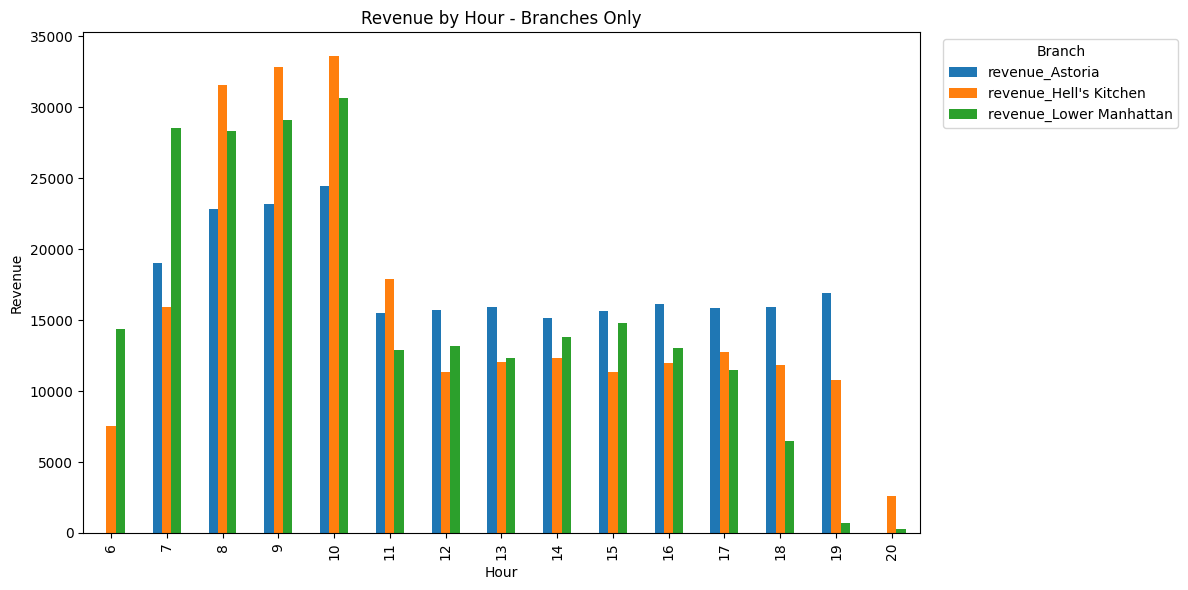

In [25]:
# Branch-only chart: revenue by hour
if "revenue_by_hour" not in globals() or revenue_by_hour.empty:
    print("Run the hour block first.")
else:
    branch_cols = [c for c in revenue_by_hour.columns if c.startswith("revenue_")]

    if not branch_cols:
        print("No branch revenue columns found.")
    else:
        plot_df = revenue_by_hour[["hour"] + branch_cols].copy()
        plot_df = plot_df.set_index("hour")

        ax = plot_df.plot(kind="bar", figsize=(12, 6))
        ax.set_title("Revenue by Hour - Branches Only")
        ax.set_xlabel("Hour")
        ax.set_ylabel("Revenue")
        ax.legend(title="Branch", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

# יחס: זמן ומוצר לפי סניף

In [26]:
# Branch 1: Top 5 most sold products by hour
branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
branch_col = next((c for c in branch_candidates if c in df.columns), None)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if branch_col is None or product_col is None or "hour" not in df.columns:
    print("Required columns are missing (branch/product/hour).")
else:
    branch_values = sorted(df[branch_col].dropna().astype(str).unique())

    if len(branch_values) < 1:
        print("No branch values found.")
    else:
        branch_name = branch_values[0]
        group_cols = ["hour"] + [c for c in [type_col, category_col, product_col] if c is not None]

        top5_branch_1 = (
            df[df[branch_col].astype(str) == branch_name]
            .groupby(group_cols, dropna=False)
            .agg(quantity_sold=("transaction_qty", "sum"))
            .reset_index()
            .sort_values("quantity_sold", ascending=False)
            .head(5)
        )

        print(f"Top 5 products by hour for branch: {branch_name}")
        print(top5_branch_1)

Top 5 products by hour for branch: Astoria
     hour           product_type product_category             product_detail  \
139     8  Premium brewed coffee           Coffee   Jamaican Coffee River Rg   
150     9       Barista Espresso           Coffee                 Cappuccino   
90      8        Brewed Chai tea              Tea   Spicy Eye Opener Chai Rg   
87      8        Brewed Chai tea              Tea    Morning Sunrise Chai Lg   
189     9  Gourmet brewed coffee           Coffee  Columbian Medium Roast Rg   

     quantity_sold  
139            244  
150            202  
90             202  
87             201  
189            200  


In [27]:
# Branch 2: Top 5 most sold products by hour
branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
branch_col = next((c for c in branch_candidates if c in df.columns), None)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if branch_col is None or product_col is None or "hour" not in df.columns:
    print("Required columns are missing (branch/product/hour).")
else:
    branch_values = sorted(df[branch_col].dropna().astype(str).unique())

    if len(branch_values) < 2:
        print("Less than 2 branches found.")
    else:
        branch_name = branch_values[1]
        group_cols = ["hour"] + [c for c in [type_col, category_col, product_col] if c is not None]

        top5_branch_2 = (
            df[df[branch_col].astype(str) == branch_name]
            .groupby(group_cols, dropna=False)
            .agg(quantity_sold=("transaction_qty", "sum"))
            .reset_index()
            .sort_values("quantity_sold", ascending=False)
            .head(5)
        )

        print(f"Top 5 products by hour for branch: {branch_name}")
        print(top5_branch_2)

Top 5 products by hour for branch: Hell's Kitchen
     hour           product_type product_category        product_detail  \
344    10  Gourmet brewed coffee           Coffee           Ethiopia Lg   
305    10       Barista Espresso           Coffee              Latte Rg   
148     8       Barista Espresso           Coffee                 Latte   
306    10       Barista Espresso           Coffee  Ouro Brasileiro shot   
228     9       Barista Espresso           Coffee  Ouro Brasileiro shot   

     quantity_sold  
344            290  
305            271  
148            271  
306            268  
228            259  


In [28]:
# Branch 3: Top 5 most sold products by hour
branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
branch_col = next((c for c in branch_candidates if c in df.columns), None)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if branch_col is None or product_col is None or "hour" not in df.columns:
    print("Required columns are missing (branch/product/hour).")
else:
    branch_values = sorted(df[branch_col].dropna().astype(str).unique())

    if len(branch_values) < 3:
        print("Less than 3 branches found.")
    else:
        branch_name = branch_values[2]
        group_cols = ["hour"] + [c for c in [type_col, category_col, product_col] if c is not None]

        top5_branch_3 = (
            df[df[branch_col].astype(str) == branch_name]
            .groupby(group_cols, dropna=False)
            .agg(quantity_sold=("transaction_qty", "sum"))
            .reset_index()
            .sort_values("quantity_sold", ascending=False)
            .head(5)
        )

        print(f"Top 5 products by hour for branch: {branch_name}")
        print(top5_branch_3)

Top 5 products by hour for branch: Lower Manhattan
     hour           product_type product_category            product_detail  \
97      7      Brewed herbal tea              Tea             Peppermint Lg   
238     9       Brewed Black tea              Tea              Earl Grey Rg   
165     8        Brewed Chai tea              Tea   Morning Sunrise Chai Lg   
319    10       Brewed Black tea              Tea      English Breakfast Rg   
373    10  Premium brewed coffee           Coffee  Jamaican Coffee River Rg   

     quantity_sold  
97             301  
238            266  
165            266  
319            265  
373            259  


# המוצרים הנמכרים ביותר בשעות השיא

In [29]:
# Top 5 most sold products at hours 8, 9, 10 (all branches combined)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if product_col is None or "hour" not in df.columns:
    print("Required columns are missing (product/hour).")
else:
    group_cols = [c for c in [type_col, category_col, product_col] if c is not None]

    top5_peak_hours_products = (
        df[df["hour"].isin([8, 9, 10])]
        .groupby(group_cols, dropna=False)
        .agg(quantity_sold=("transaction_qty", "sum"))
        .reset_index()
        .sort_values("quantity_sold", ascending=False)
        .head(5)
    )

    print("Top 5 most sold products at hours 8, 9, 10 (all branches):")
    print(top5_peak_hours_products)

Top 5 most sold products at hours 8, 9, 10 (all branches):
             product_type product_category           product_detail  \
26      Brewed herbal tea              Tea            Peppermint Rg   
4        Barista Espresso           Coffee                 Latte Rg   
12       Brewed Black tea              Tea             Earl Grey Rg   
43  Gourmet brewed coffee           Coffee              Ethiopia Lg   
15        Brewed Chai tea              Tea  Morning Sunrise Chai Lg   

    quantity_sold  
26           1695  
4            1669  
12           1650  
43           1634  
15           1606  


# Revenue לפי product_detail עם איחוד גדלים

איחוד שמות מוצרים שמסתיימים ב- sm/rg/lg/xl לאותו מוצר בסיסי, ואז חישוב total revenue לכל מוצר מאוחד.

In [30]:
# Revenue by unified product_detail (merge size variants into one product)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)

if product_col is None:
    print("Product detail column not found.")
else:
    work_df = df.copy()

    # Treat trailing size suffixes as the same base product
    work_df["product_base"] = (
        work_df[product_col]
        .astype(str)
        .str.strip()
        .str.replace(r"(?:\s+(sm|rg|lg|xl))+$", "", regex=True, case=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    unified_product_revenue = (
        work_df.groupby("product_base", dropna=False)
        .agg(
            total_revenue=("revenue", "sum"),
            total_quantity=("transaction_qty", "sum"),
            size_variants_count=(product_col, "nunique"),
            size_variants=(product_col, lambda s: ", ".join(sorted(pd.unique(s.astype(str)))))
        )
        .reset_index()
        .sort_values("total_revenue", ascending=False)
    )

    unified_product_revenue["total_revenue"] = unified_product_revenue["total_revenue"].round(2)

    print("Revenue by unified product_detail (sizes merged):")
    print(f"Rows: {len(unified_product_revenue):,}")
    print(unified_product_revenue)

Revenue by unified product_detail (sizes merged):
Rows: 45
                    product_base  total_revenue  total_quantity  \
18                      Ethiopia       42304.10           13271   
43     Sustainably Grown Organic       39065.10            9003   
28         Jamaican Coffee River       38781.15           12431   
1                      Brazilian       37746.50           13012   
30                         Latte       36369.75            9099   
13                Dark chocolate       35785.70            8793   
35      Our Old Time Diner Blend       35278.00           13074   
10        Columbian Medium Roast       34528.50           13068   
3                     Cappuccino       33639.25            8417   
32          Morning Sunrise Chai       30587.50            9157   
37                    Peppermint       25829.35            9067   
14                     Earl Grey       25775.90            9095   
41         Spicy Eye Opener Chai       25624.35            8697   
40 

# גרפים: 10 מוצרים הכי נמכרים והכי פחות נמכרים (אחרי איחוד גדלים)

הגרפים מבוססים על `total_quantity` מתוך `unified_product_revenue`.

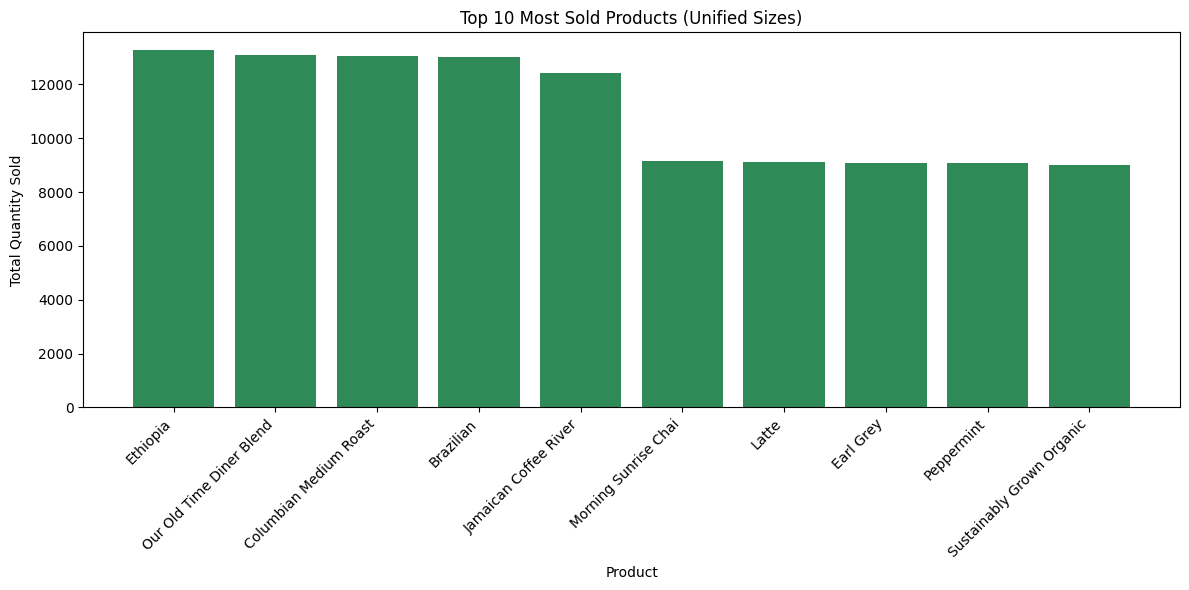

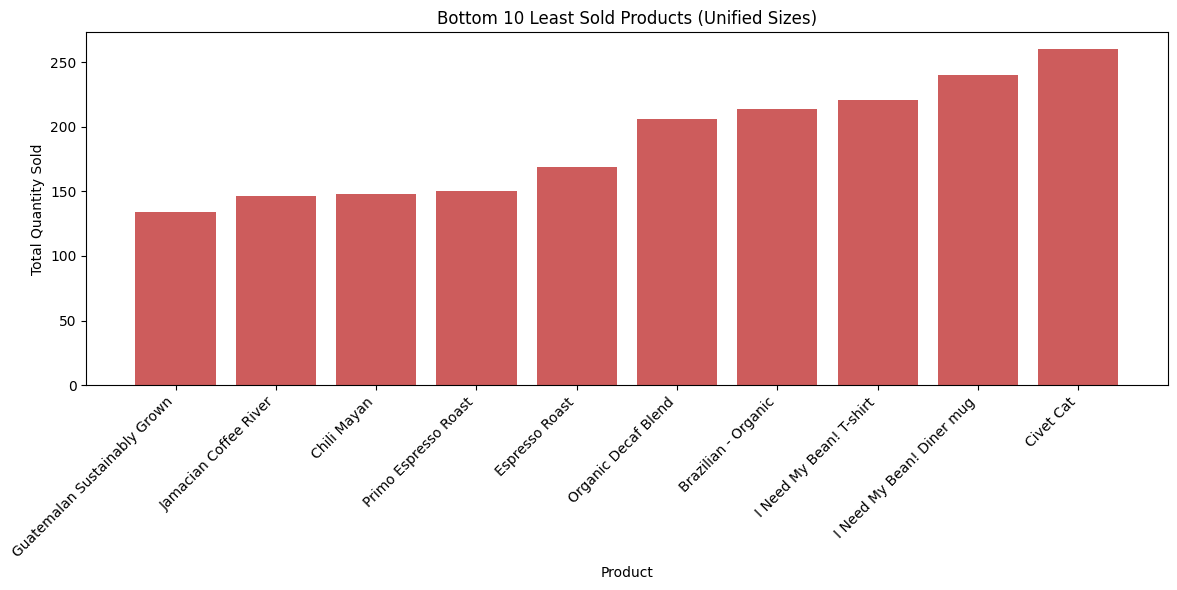

In [31]:
import matplotlib.pyplot as plt

if "unified_product_revenue" not in globals() or unified_product_revenue.empty:
    print("Run the unified product revenue cell first.")
else:
    # 10 most sold products (highest quantity)
    top10_sold = unified_product_revenue.nlargest(10, "total_quantity").copy()

    plt.figure(figsize=(12, 6))
    plt.bar(top10_sold["product_base"], top10_sold["total_quantity"], color="seagreen")
    plt.title("Top 10 Most Sold Products (Unified Sizes)")
    plt.xlabel("Product")
    plt.ylabel("Total Quantity Sold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 10 least sold products (lowest quantity)
    bottom10_sold = unified_product_revenue.nsmallest(10, "total_quantity").copy()

    plt.figure(figsize=(12, 6))
    plt.bar(bottom10_sold["product_base"], bottom10_sold["total_quantity"], color="indianred")
    plt.title("Bottom 10 Least Sold Products (Unified Sizes)")
    plt.xlabel("Product")
    plt.ylabel("Total Quantity Sold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# יחס: זמן ומוצר לפי סניף (עם איחוד גדלים)

אותו חישוב כמו למעלה, אבל עם איחוד שמות מוצרים לפי גדלים (`sm/rg/lg/xl`).

In [32]:
# Branch 3: Top 5 most sold products by hour (sizes merged)
branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
branch_col = next((c for c in branch_candidates if c in df.columns), None)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if branch_col is None or product_col is None or "hour" not in df.columns:
    print("Required columns are missing (branch/product/hour).")
else:
    work_df = df.copy()
    work_df["product_base"] = (
        work_df[product_col]
        .astype(str)
        .str.strip()
        .str.replace(r"(?:\s+(sm|rg|lg|xl))+$", "", regex=True, case=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    branch_values = sorted(work_df[branch_col].dropna().astype(str).unique())

    if len(branch_values) < 3:
        print("Less than 3 branches found.")
    else:
        branch_name = branch_values[2]
        group_cols = ["hour"] + [c for c in [type_col, category_col, "product_base"] if c is not None]

        top5_branch_3_sizes_merged = (
            work_df[work_df[branch_col].astype(str) == branch_name]
            .groupby(group_cols, dropna=False)
            .agg(quantity_sold=("transaction_qty", "sum"))
            .reset_index()
            .sort_values("quantity_sold", ascending=False)
            .head(5)
        )

        print(f"Top 5 products by hour for branch (sizes merged): {branch_name}")
        print(top5_branch_3_sizes_merged)

Top 5 products by hour for branch (sizes merged): Lower Manhattan
     hour           product_type product_category            product_base  \
207     9  Premium brewed coffee           Coffee   Jamaican Coffee River   
264    10  Premium brewed coffee           Coffee   Jamaican Coffee River   
90      7  Organic brewed coffee           Coffee               Brazilian   
258    10  Organic brewed coffee           Coffee               Brazilian   
188     9  Gourmet brewed coffee           Coffee  Columbian Medium Roast   

     quantity_sold  
207            608  
264            588  
90             575  
258            562  
188            555  


In [33]:
# Branch 2: Top 5 most sold products by hour (sizes merged)
branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
branch_col = next((c for c in branch_candidates if c in df.columns), None)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if branch_col is None or product_col is None or "hour" not in df.columns:
    print("Required columns are missing (branch/product/hour).")
else:
    work_df = df.copy()
    work_df["product_base"] = (
        work_df[product_col]
        .astype(str)
        .str.strip()
        .str.replace(r"(?:\s+(sm|rg|lg|xl))+$", "", regex=True, case=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    branch_values = sorted(work_df[branch_col].dropna().astype(str).unique())

    if len(branch_values) < 2:
        print("Less than 2 branches found.")
    else:
        branch_name = branch_values[1]
        group_cols = ["hour"] + [c for c in [type_col, category_col, "product_base"] if c is not None]

        top5_branch_2_sizes_merged = (
            work_df[work_df[branch_col].astype(str) == branch_name]
            .groupby(group_cols, dropna=False)
            .agg(quantity_sold=("transaction_qty", "sum"))
            .reset_index()
            .sort_values("quantity_sold", ascending=False)
            .head(5)
        )

        print(f"Top 5 products by hour for branch (sizes merged): {branch_name}")
        print(top5_branch_2_sizes_merged)

Top 5 products by hour for branch (sizes merged): Hell's Kitchen
     hour           product_type product_category              product_base  \
242    10  Gourmet brewed coffee           Coffee                  Ethiopia   
255    10  Organic brewed coffee           Coffee                 Brazilian   
179     9            Drip coffee           Coffee  Our Old Time Diner Blend   
141     8  Organic brewed coffee           Coffee                 Brazilian   
236    10            Drip coffee           Coffee  Our Old Time Diner Blend   

     quantity_sold  
242            664  
255            619  
179            614  
141            606  
236            602  


In [34]:
# Branch 1: Top 5 most sold products by hour (sizes merged)
branch_candidates = ["store_location", "store_id", "branch", "branch_id", "location", "store"]
branch_col = next((c for c in branch_candidates if c in df.columns), None)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if branch_col is None or product_col is None or "hour" not in df.columns:
    print("Required columns are missing (branch/product/hour).")
else:
    work_df = df.copy()
    work_df["product_base"] = (
        work_df[product_col]
        .astype(str)
        .str.strip()
        .str.replace(r"(?:\s+(sm|rg|lg|xl))+$", "", regex=True, case=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    branch_values = sorted(work_df[branch_col].dropna().astype(str).unique())

    if len(branch_values) < 1:
        print("No branch values found.")
    else:
        branch_name = branch_values[0]
        group_cols = ["hour"] + [c for c in [type_col, category_col, "product_base"] if c is not None]

        top5_branch_1_sizes_merged = (
            work_df[work_df[branch_col].astype(str) == branch_name]
            .groupby(group_cols, dropna=False)
            .agg(quantity_sold=("transaction_qty", "sum"))
            .reset_index()
            .sort_values("quantity_sold", ascending=False)
            .head(5)
        )

        print(f"Top 5 products by hour for branch (sizes merged): {branch_name}")
        print(top5_branch_1_sizes_merged)

Top 5 products by hour for branch (sizes merged): Astoria
     hour           product_type product_category            product_base  \
96      8  Premium brewed coffee           Coffee   Jamaican Coffee River   
132     9  Gourmet brewed coffee           Coffee  Columbian Medium Roast   
200    10  Organic brewed coffee           Coffee               Brazilian   
77      8  Gourmet brewed coffee           Coffee                Ethiopia   
188    10  Gourmet brewed coffee           Coffee                Ethiopia   

     quantity_sold  
96             518  
132            509  
200            477  
77             476  
188            474  


# המוצרים הנמכרים ביותר בשעות השיא (עם איחוד גדלים)

אותו חישוב של שעות 8, 9, 10 אבל עם איחוד שמות מוצרים לפי גדלים.

In [35]:
# Top 5 most sold products at hours 8, 9, 10 (all branches, sizes merged)
product_col = "product_detail" if "product_detail" in df.columns else ("product" if "product" in df.columns else None)
category_col = "product_category" if "product_category" in df.columns else None
type_col = "product_type" if "product_type" in df.columns else None

if product_col is None or "hour" not in df.columns:
    print("Required columns are missing (product/hour).")
else:
    work_df = df.copy()
    work_df["product_base"] = (
        work_df[product_col]
        .astype(str)
        .str.strip()
        .str.replace(r"(?:\s+(sm|rg|lg|xl))+$", "", regex=True, case=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    group_cols = [c for c in [type_col, category_col, "product_base"] if c is not None]

    top5_peak_hours_products_sizes_merged = (
        work_df[work_df["hour"].isin([8, 9, 10])]
        .groupby(group_cols, dropna=False)
        .agg(quantity_sold=("transaction_qty", "sum"))
        .reset_index()
        .sort_values("quantity_sold", ascending=False)
        .head(5)
    )

    print("Top 5 most sold products at hours 8, 9, 10 (all branches, sizes merged):")
    print(top5_peak_hours_products_sizes_merged)

Top 5 most sold products at hours 8, 9, 10 (all branches, sizes merged):
             product_type product_category              product_base  \
29  Gourmet brewed coffee           Coffee                  Ethiopia   
42  Organic brewed coffee           Coffee                 Brazilian   
48  Premium brewed coffee           Coffee     Jamaican Coffee River   
28  Gourmet brewed coffee           Coffee    Columbian Medium Roast   
23            Drip coffee           Coffee  Our Old Time Diner Blend   

    quantity_sold  
29           4710  
42           4579  
48           4467  
28           4393  
23           4360  
